In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from scipy.stats import norm
import json
from matplotlib.colors import ListedColormap

In [14]:
# Установка стиля для графиков
plt.style.use('seaborn-v0_8-darkgrid')

In [15]:
# 1. Загрузка данных Iris
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [16]:
# Выбираем два признака для 2D визуализации: petal length (2) и petal width (3)
feature_indices = [2, 3]
X_2d = X[:, feature_indices]
selected_feature_names = [feature_names[i] for i in feature_indices]

print(f"Выбранные признаки для визуализации: {selected_feature_names[0]} и {selected_feature_names[1]}")

Выбранные признаки для визуализации: petal length (cm) и petal width (cm)


In [17]:
# 2. Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]} объектов")
print(f"Размер тестовой выборки: {X_test.shape[0]} объектов")


Размер обучающей выборки: 105 объектов
Размер тестовой выборки: 45 объектов


In [18]:
# 3. Собственная реализация Байесовского классификатора (Naive Bayes с Gaussian PDF)
class CustomGaussianNaiveBayes:
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        self.n_features_ = X.shape[1]
        self.means_ = np.zeros((self.n_classes_, self.n_features_))
        self.stds_ = np.zeros((self.n_classes_, self.n_features_))
        self.priors_ = np.zeros(self.n_classes_)

        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.means_[i, :] = X_c.mean(axis=0)
            # Добавляем небольшую константу, чтобы избежать нулевого стандартного отклонения
            self.stds_[i, :] = X_c.std(axis=0) + 1e-6
            self.priors_[i] = len(X_c) / len(X)

    def _gaussian_pdf(self, X, class_idx, feature_idx):
        mean = self.means_[class_idx, feature_idx]
        std = self.stds_[class_idx, feature_idx]
        return norm.pdf(X, loc=mean, scale=std)

    def predict_proba(self, X):
        n_samples = X.shape[0]
        posteriors = np.zeros((n_samples, self.n_classes_))

        for i, c in enumerate(self.classes_):
            # Log-likelihood для числовой стабильности
            # Умножаем вероятности признаков, что в логарифмическом масштабе превращается в суммирование логарифмов.
            # Для каждого признака j в X[sample_idx, j] вычисляем PDF. Нужна плотность для каждой точки X_i и каждого признака f.
            # log(P(x|c)) = sum(log(P(x_j|c)))
            log_likelihoods = np.array([
                np.log(self._gaussian_pdf(X[:, j], i, j))
                for j in range(self.n_features_)
            ])
            log_class_likelihood = np.sum(log_likelihoods, axis=0)

            posteriors[:, i] = log_class_likelihood + np.log(self.priors_[i])

        # Преобразуем обратно из логарифмического масштаба и нормализуем, чтобы получить вероятности
        # Используем exp-normalize trick для устойчивости
        max_log_posterior = np.max(posteriors, axis=1, keepdims=True)
        exp_posterior = np.exp(posteriors - max_log_posterior)
        sum_exp_posterior = np.sum(exp_posterior, axis=1, keepdims=True)
        probabilities = exp_posterior / sum_exp_posterior

        return probabilities

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.argmax(probabilities, axis=1)

In [19]:
# Обучение классификатора
classifier = CustomGaussianNaiveBayes()
classifier.fit(X_train, y_train)

In [20]:
# Прогнозы для обучающей и тестовой выборок
y_train_pred = classifier.predict(X_train)
y_test_pred = classifier.predict(X_test)

In [21]:
# Ошибки классификации
train_errors = y_train_pred != y_train
test_errors = y_test_pred != y_test

print(f"Количество ошибок на обучающей выборке: {np.sum(train_errors)} из {len(y_train)}")
print(f"Количество ошибок на тестовой выборке: {np.sum(test_errors)} из {len(y_test)}")

Количество ошибок на обучающей выборке: 6 из 105
Количество ошибок на тестовой выборке: 0 из 45


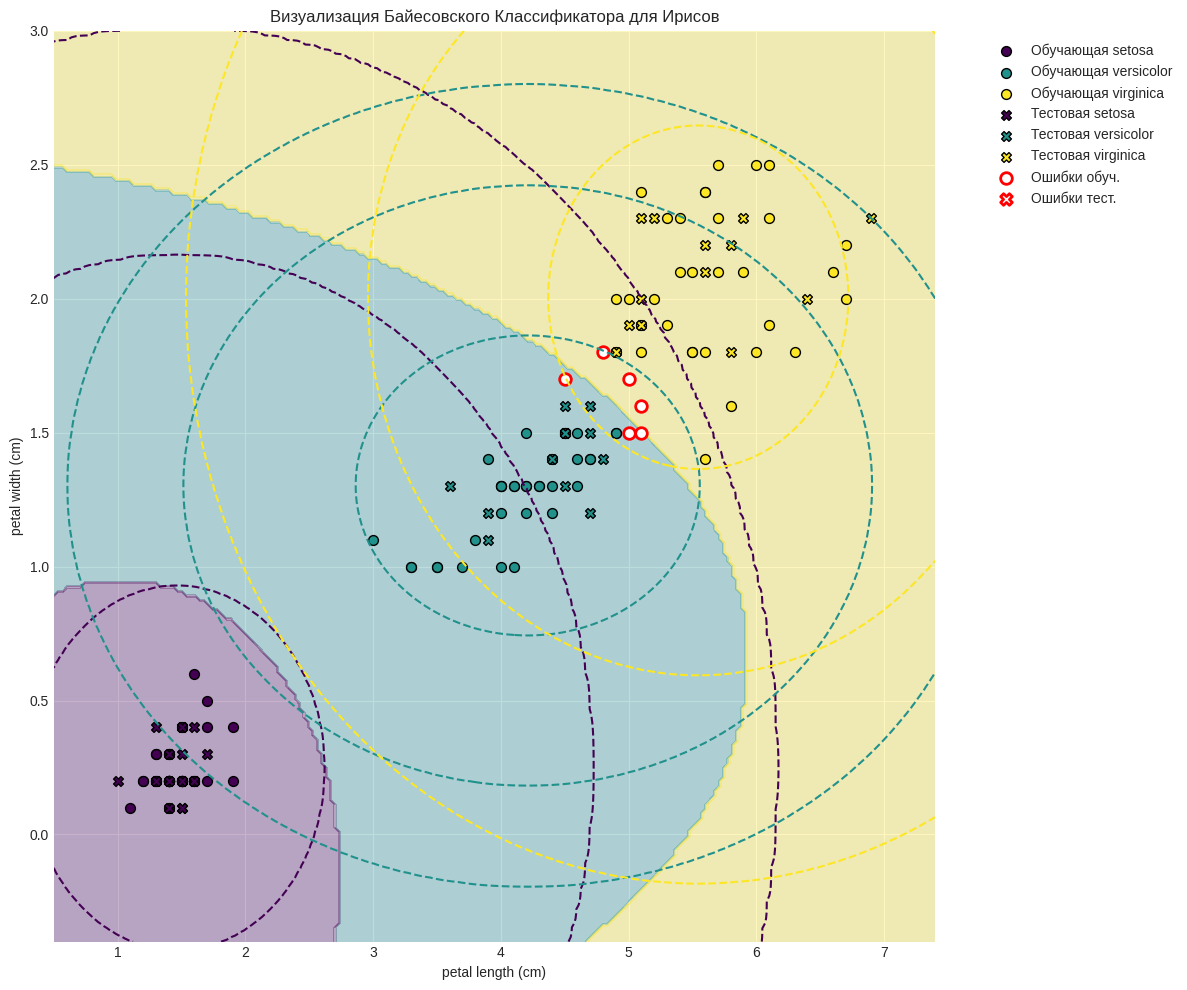

In [22]:
# 4. Визуализация
plt.figure(figsize=(12, 10))

# Получаем базовую непрерывную карту цветов
base_cmap = plt.colormaps['viridis']

# Создаем дискретные карты цветов на основе базовой, для использования с contourf
n_classes = classifier.n_classes_
cmap_light = ListedColormap(base_cmap(np.linspace(0, 1, n_classes)), name='viridis_light_discrete')
cmap_bold = ListedColormap(base_cmap(np.linspace(0, 1, n_classes)), name='viridis_bold_discrete')

colors = [cmap_bold.colors[i] for i in range(n_classes)]

error_color = 'white'
alpha_contour = 0.3

# Определение границ для сетки
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Показываем разделяющие границы байесовского классификатора
plt.contourf(xx, yy, Z, alpha=alpha_contour, cmap=cmap_light)

# Показываем линии уровня плотности распределения для 3х классов
for i, c in enumerate(classifier.classes_):
    # Создаем 2D-сетку для плотности для каждого класса
    Z_density = norm.pdf(xx, loc=classifier.means_[i, 0], scale=classifier.stds_[i, 0]) * \
                norm.pdf(yy, loc=classifier.means_[i, 1], scale=classifier.stds_[i, 1])

    # Масштабируем плотность, чтобы контуры были хорошо видны
    # Выбираем несколько уровней для контуров, 30, 60, 90 перцентилей
    levels = np.percentile(Z_density.flatten(), [30, 60, 90])
    plt.contour(xx, yy, Z_density, levels=levels, colors=[colors[i]], linestyles='--')


# Отображаем обучающие точки
for i, c in enumerate(classifier.classes_):
    plt.scatter(X_train[y_train == c, 0], X_train[y_train == c, 1],
                c=[colors[i]], marker='o', edgecolor='k', s=50, label=f'Обучающая {target_names[c]}')

# Отображаем тестовые точки
for i, c in enumerate(classifier.classes_):
    plt.scatter(X_test[y_test == c, 0], X_test[y_test == c, 1],
                c=[colors[i]], marker='X', edgecolor='k', s=50, label=f'Тестовая {target_names[c]}')

# Показываем ошибки классификации
plt.scatter(X_train[train_errors, 0], X_train[train_errors, 1],
            facecolors=error_color, marker='o', edgecolor='red', s=70, linewidth=2, label='Ошибки обуч.')
plt.scatter(X_test[test_errors, 0], X_test[test_errors, 1],
            facecolors=error_color, marker='X', edgecolor='red', s=70, linewidth=2, label='Ошибки тест.')


plt.xlabel(selected_feature_names[0])
plt.ylabel(selected_feature_names[1])
plt.title('Визуализация Байесовского Классификатора для Ирисов')

# Создаем легенду
handles, labels = plt.gca().get_legend_handles_labels()
# Удаляем дубликаты из легенды
unique_labels = dict(zip(labels, handles))
plt.legend(unique_labels.values(), unique_labels.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
